--- ĐANG ĐỌC DỮ LIỆU ĐẶC TRƯNG TỪ FILE CSV ---
✅ Đã nạp thành công bộ dữ liệu! Tổng số mẫu: 20

--- ĐANG TRAINNING MÔ HÌNH NAIVE BAYES ---
✅ Huấn luyện hoàn tất!

==> ĐỘ CHÍNH XÁC CỦA BAYESIAN CLASSIFIER: 25.00%

Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

         cat       0.33      0.50      0.40         2
         dog       0.00      0.00      0.00         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4



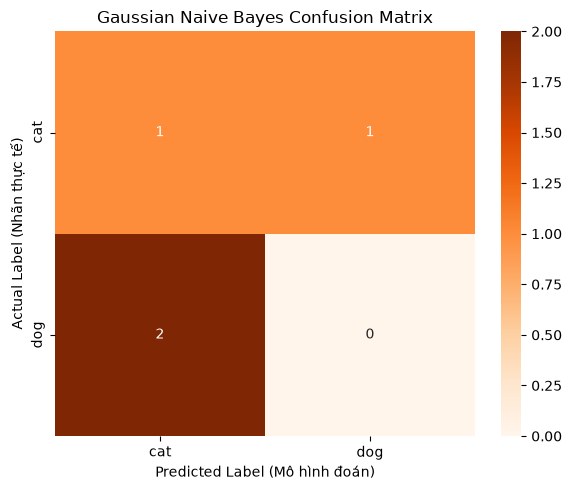

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. ĐƯỜNG DẪN ĐỌC FILE CSV CHUẨN TỪ THƯ MỤC SRC ĐI LÙI RA DATA
csv_path = '../data/dog_cat_features.csv'

if not os.path.exists(csv_path):
    print(f"❌ Không tìm thấy file dữ liệu tại: {csv_path}. Bạn hãy chạy file trích xuất đặc trưng trước!")
    exit()

print("--- ĐANG ĐỌC DỮ LIỆU ĐẶC TRƯNG TỪ FILE CSV ---")
df = pd.read_csv(csv_path)
print(f"✅ Đã nạp thành công bộ dữ liệu! Tổng số mẫu: {len(df)}")

# 2. TÁCH ĐẶC TRƯNG (X) VÀ NHÃN (Y)
X = df.drop(columns=['Label'])
y = df['Label']

# Chia tập dữ liệu: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH NAIVE BAYES
print("\n--- ĐANG TRAINNING MÔ HÌNH NAIVE BAYES ---")
model_bayes = GaussianNB()
model_bayes.fit(X_train, y_train)
print("✅ Huấn luyện hoàn tất!")

# 4. ĐÁNH GIÁ ĐỘ CHÍNH XÁC (Đã fix lỗi gõ sai tên biến ở đây)
y_pred = model_bayes.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) 
print(f"\n==> ĐỘ CHÍNH XÁC CỦA BAYESIAN CLASSIFIER: {accuracy * 100:.2f}%\n")

# In thêm bảng báo cáo chi tiết để lấy số liệu làm slide thuyết trình
print("Báo cáo phân loại chi tiết (Classification Report):")
categories = sorted(y.unique())
print(classification_report(y_test, y_pred, target_names=categories))

# 5. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) CỦA THÀNH VIÊN 1
cm = confusion_matrix(y_test, y_pred, labels=categories)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=categories, yticklabels=categories)
plt.ylabel('Actual Label (Nhãn thực tế)')
plt.xlabel('Predicted Label (Mô hình đoán)')
plt.title('Gaussian Naive Bayes Confusion Matrix')
plt.tight_layout()
plt.show()